In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.rcParams['figure.dpi'] = 130
print("Ready ✓")

Ready ✓


In [2]:
def load_coin(path, name):
    df = pd.read_csv(path, index_col='date', parse_dates=True)
    df['coin'] = name
    return df

btc = load_coin('../data/btc_raw.csv', 'BTC')
eth = load_coin('../data/eth_raw.csv', 'ETH')
sol = load_coin('../data/sol_raw.csv', 'SOL')

# Quick inspection
for name, df in [('BTC', btc), ('ETH', eth), ('SOL', sol)]:
    print(f"\n{name} — shape: {df.shape}")
    print(f"  Date range: {df.index.min().date()} → {df.index.max().date()}")
    print(f"  Nulls: {df.isnull().sum().to_dict()}")


BTC — shape: (1095, 6)
  Date range: 2022-01-01 → 2024-12-30
  Nulls: {'close': 0, 'high': 0, 'low': 0, 'open': 0, 'volume': 0, 'coin': 0}

ETH — shape: (1095, 6)
  Date range: 2022-01-01 → 2024-12-30
  Nulls: {'close': 0, 'high': 0, 'low': 0, 'open': 0, 'volume': 0, 'coin': 0}

SOL — shape: (1095, 6)
  Date range: 2022-01-01 → 2024-12-30
  Nulls: {'close': 0, 'high': 0, 'low': 0, 'open': 0, 'volume': 0, 'coin': 0}


In [3]:
def clean_ohlcv(df):
    # Forward fill small gaps (weekends/holidays in some sources)
    df = df.ffill()
    
    # Drop any remaining nulls
    df = df.dropna()
    
    # Sort chronologically just in case
    df = df.sort_index()
    
    # Remove duplicates
    df = df[~df.index.duplicated(keep='first')]
    
    return df

btc = clean_ohlcv(btc)
eth = clean_ohlcv(eth)
sol = clean_ohlcv(sol)

print(f"BTC clean shape: {btc.shape}")
print(f"ETH clean shape: {eth.shape}")
print(f"SOL clean shape: {sol.shape}")

BTC clean shape: (1095, 6)
ETH clean shape: (1095, 6)
SOL clean shape: (1095, 6)


In [4]:
def add_features(df):
    # --- Returns ---
    df['daily_return'] = df['close'].pct_change()           # % change day-to-day
    df['log_return']   = np.log(df['close'] / df['close'].shift(1))

    # --- Moving Averages ---
    df['ma_7']  = df['close'].rolling(window=7).mean()      # 1-week trend
    df['ma_30'] = df['close'].rolling(window=30).mean()     # 1-month trend
    df['ma_90'] = df['close'].rolling(window=90).mean()     # 3-month trend

    # --- Volatility ---
    df['volatility_7d']  = df['daily_return'].rolling(7).std()
    df['volatility_30d'] = df['daily_return'].rolling(30).std()

    # --- Bollinger Bands (20-day) ---
    rolling_mean = df['close'].rolling(20).mean()
    rolling_std  = df['close'].rolling(20).std()
    df['bb_upper'] = rolling_mean + (2 * rolling_std)
    df['bb_lower'] = rolling_mean - (2 * rolling_std)
    df['bb_mid']   = rolling_mean

    # --- Price range ---
    df['daily_range'] = df['high'] - df['low']

    # Drop NaN rows created by rolling windows
    df = df.dropna()
    return df

btc = add_features(btc)
eth = add_features(eth)
sol = add_features(sol)

print("Features added ✓")
print(btc.columns.tolist())

Features added ✓
['close', 'high', 'low', 'open', 'volume', 'coin', 'daily_return', 'log_return', 'ma_7', 'ma_30', 'ma_90', 'volatility_7d', 'volatility_30d', 'bb_upper', 'bb_lower', 'bb_mid', 'daily_range']


In [5]:
btc.to_csv('../data/btc_clean.csv')
eth.to_csv('../data/eth_clean.csv')
sol.to_csv('../data/sol_clean.csv')
print("Clean CSVs saved ✓")

Clean CSVs saved ✓


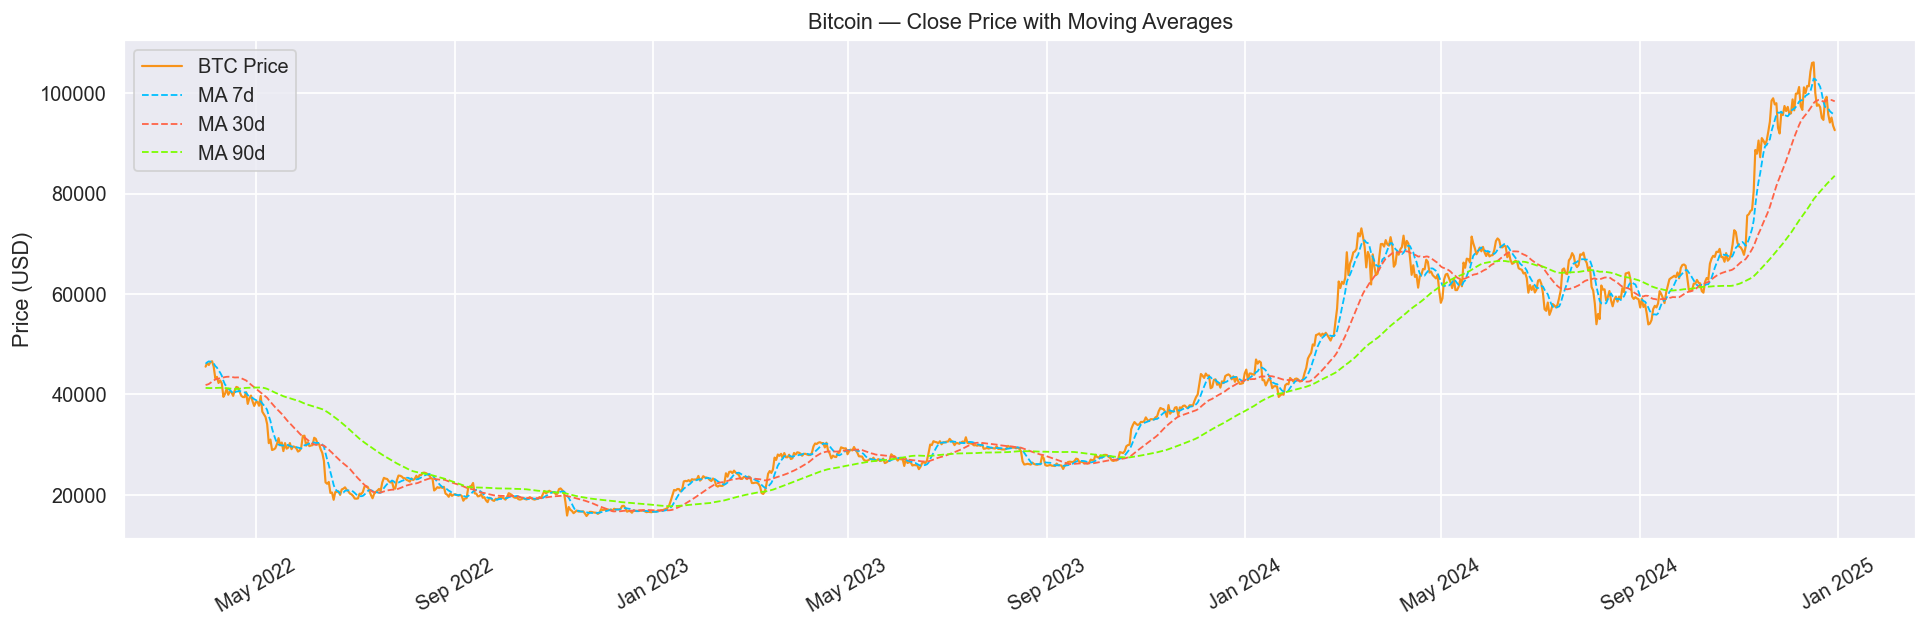

In [6]:
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(btc.index, btc['close'],  color='#F7931A', linewidth=1.2, label='BTC Price')
ax.plot(btc.index, btc['ma_7'],   color='#00BFFF', linewidth=1,   label='MA 7d',  linestyle='--')
ax.plot(btc.index, btc['ma_30'],  color='#FF6347', linewidth=1,   label='MA 30d', linestyle='--')
ax.plot(btc.index, btc['ma_90'],  color='#7CFC00', linewidth=1,   label='MA 90d', linestyle='--')

ax.set_title('Bitcoin — Close Price with Moving Averages')
ax.set_ylabel('Price (USD)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../data/btc_ma.png', dpi=150)
plt.show()

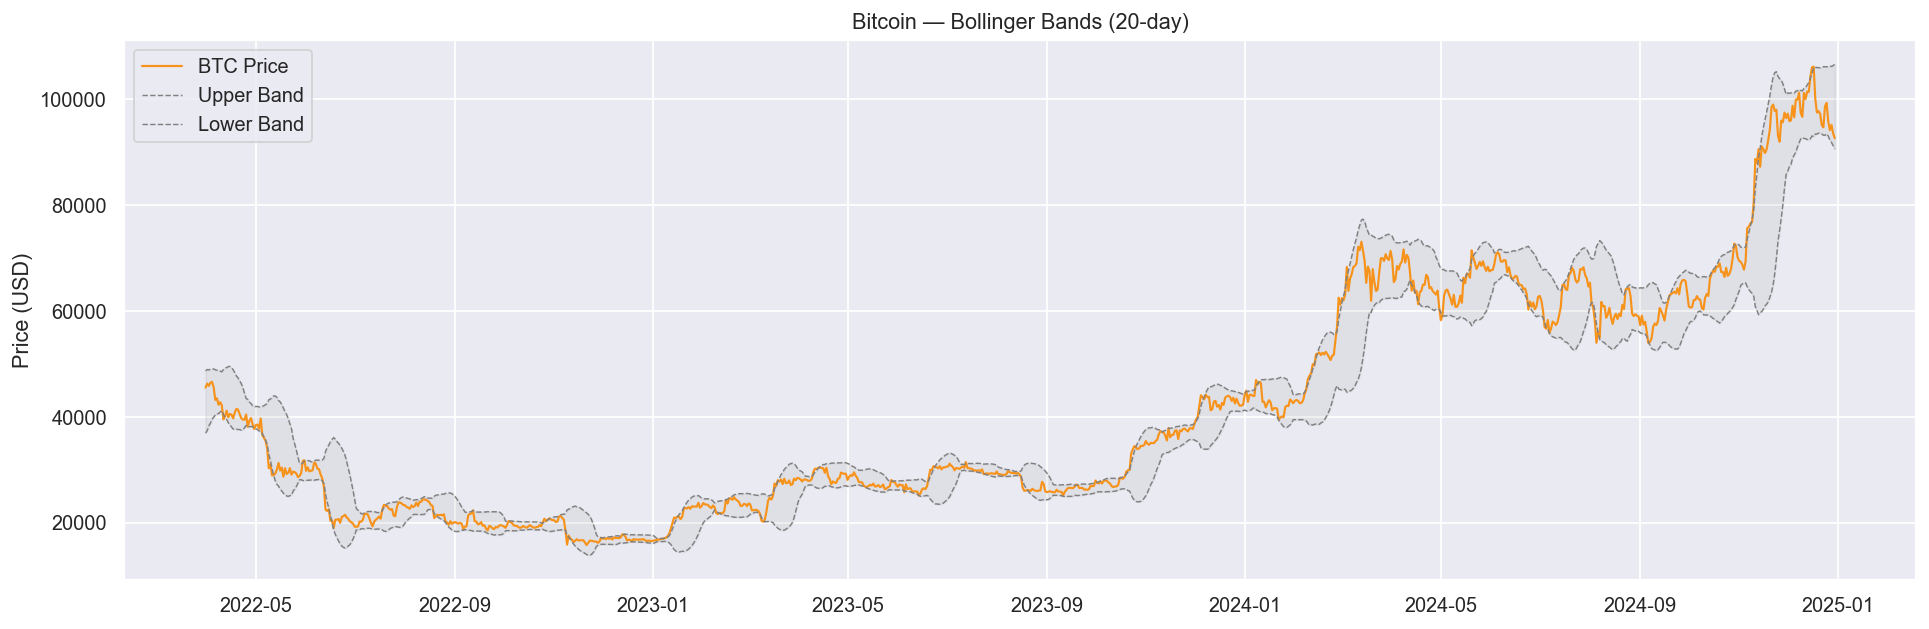

In [7]:
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(btc.index, btc['close'],    color='#F7931A', linewidth=1.2, label='BTC Price')
ax.plot(btc.index, btc['bb_upper'], color='gray',    linewidth=0.8, linestyle='--', label='Upper Band')
ax.plot(btc.index, btc['bb_lower'], color='gray',    linewidth=0.8, linestyle='--', label='Lower Band')
ax.fill_between(btc.index, btc['bb_lower'], btc['bb_upper'], alpha=0.1, color='gray')

ax.set_title('Bitcoin — Bollinger Bands (20-day)')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.tight_layout()
plt.savefig('../data/btc_bollinger.png', dpi=150)
plt.show()

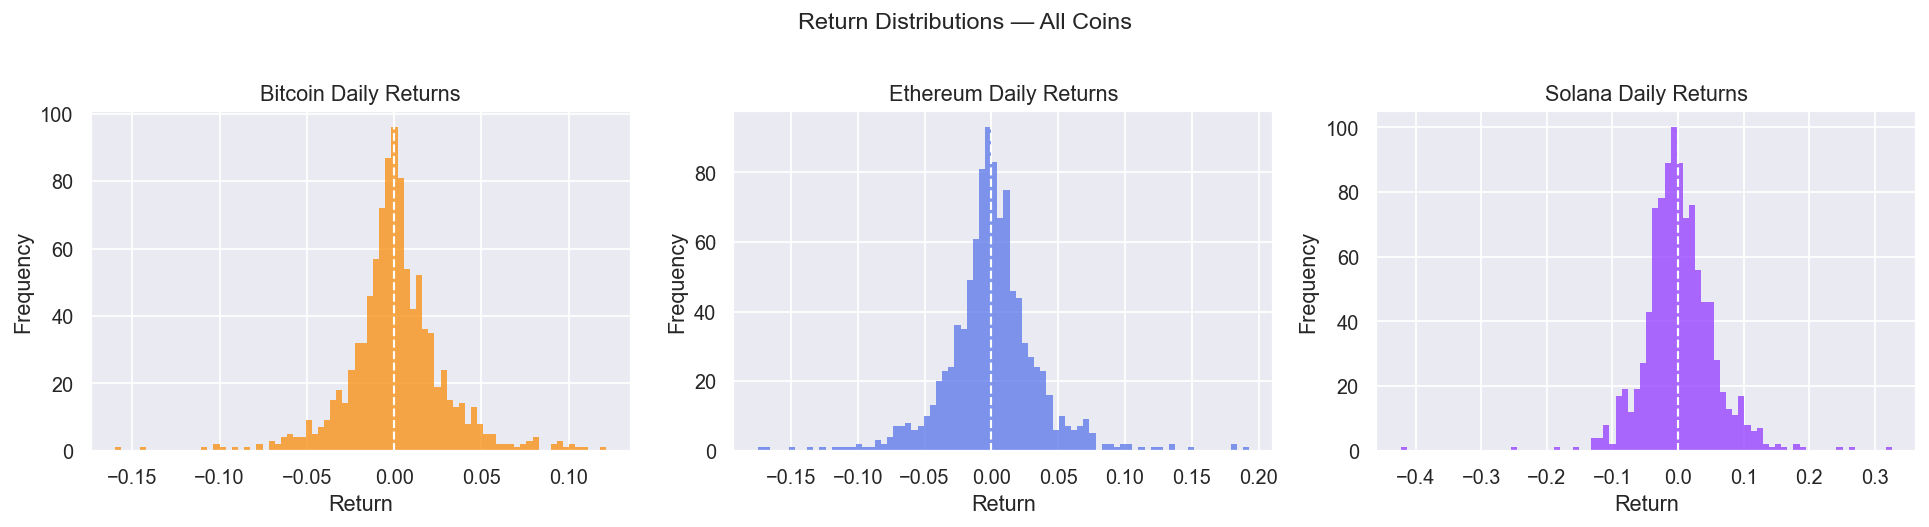

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, df, name, color in zip(
    axes,
    [btc, eth, sol],
    ['Bitcoin', 'Ethereum', 'Solana'],
    ['#F7931A', '#627EEA', '#9945FF']
):
    ax.hist(df['daily_return'], bins=80, color=color, alpha=0.8, edgecolor='none')
    ax.axvline(0, color='white', linewidth=1.2, linestyle='--')
    ax.set_title(f'{name} Daily Returns')
    ax.set_xlabel('Return')
    ax.set_ylabel('Frequency')

plt.suptitle('Return Distributions — All Coins', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../data/return_distributions.png', dpi=150)
plt.show()

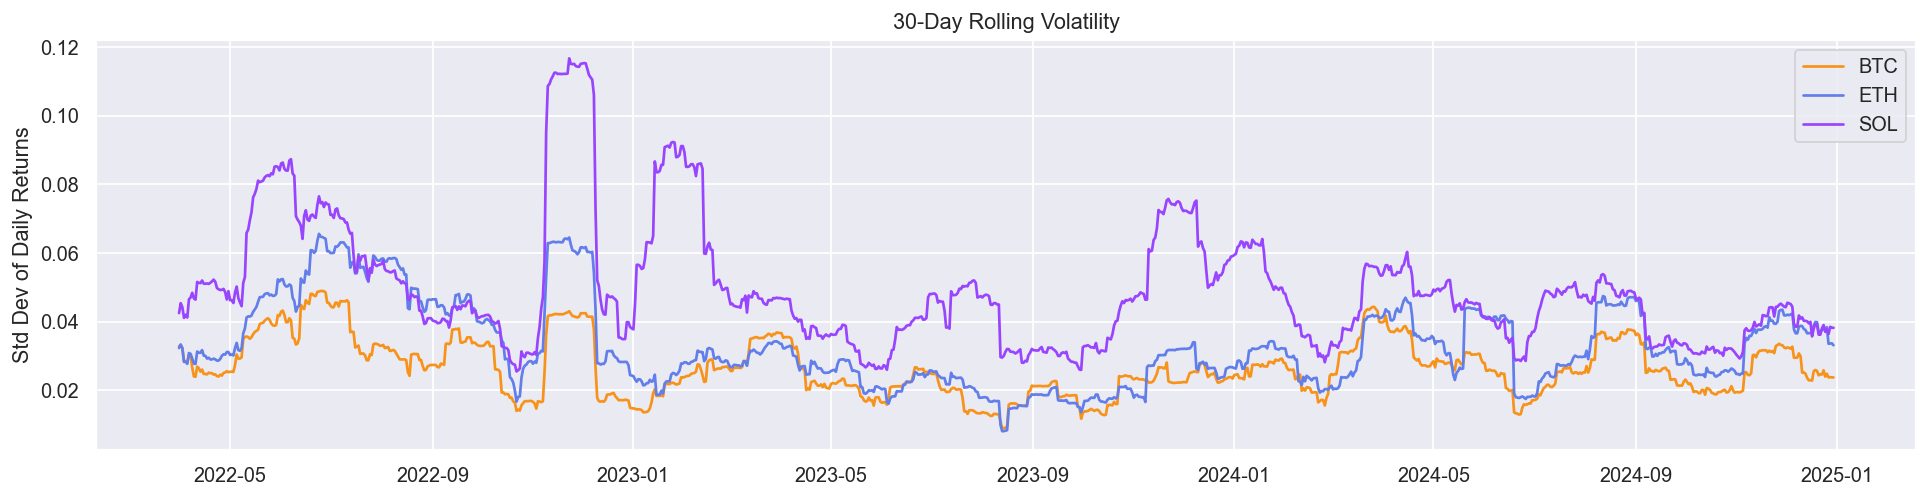

In [9]:
fig, ax = plt.subplots(figsize=(15, 4))

ax.plot(btc.index, btc['volatility_30d'], color='#F7931A', label='BTC')
ax.plot(eth.index, eth['volatility_30d'], color='#627EEA', label='ETH')
ax.plot(sol.index, sol['volatility_30d'], color='#9945FF', label='SOL')

ax.set_title('30-Day Rolling Volatility')
ax.set_ylabel('Std Dev of Daily Returns')
ax.legend()
plt.tight_layout()
plt.savefig('../data/volatility.png', dpi=150)
plt.show()

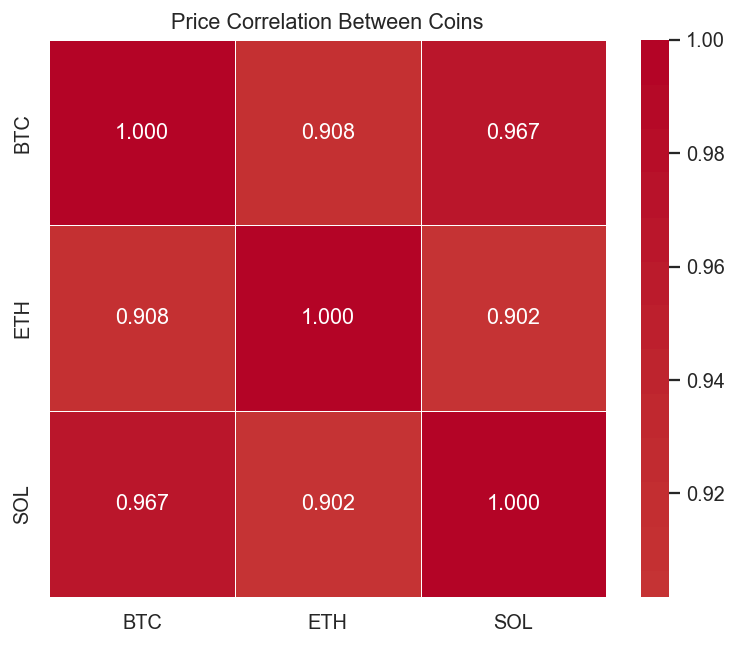

In [10]:
# Combine close prices of all 3 coins
combined = pd.DataFrame({
    'BTC': btc['close'],
    'ETH': eth['close'],
    'SOL': sol['close'],
}).dropna()

corr = combined.corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    corr,
    annot=True, fmt='.3f',
    cmap='coolwarm', center=0,
    square=True, linewidths=0.5,
    ax=ax
)
ax.set_title('Price Correlation Between Coins')
plt.tight_layout()
plt.savefig('../data/correlation_heatmap.png', dpi=150)
plt.show()

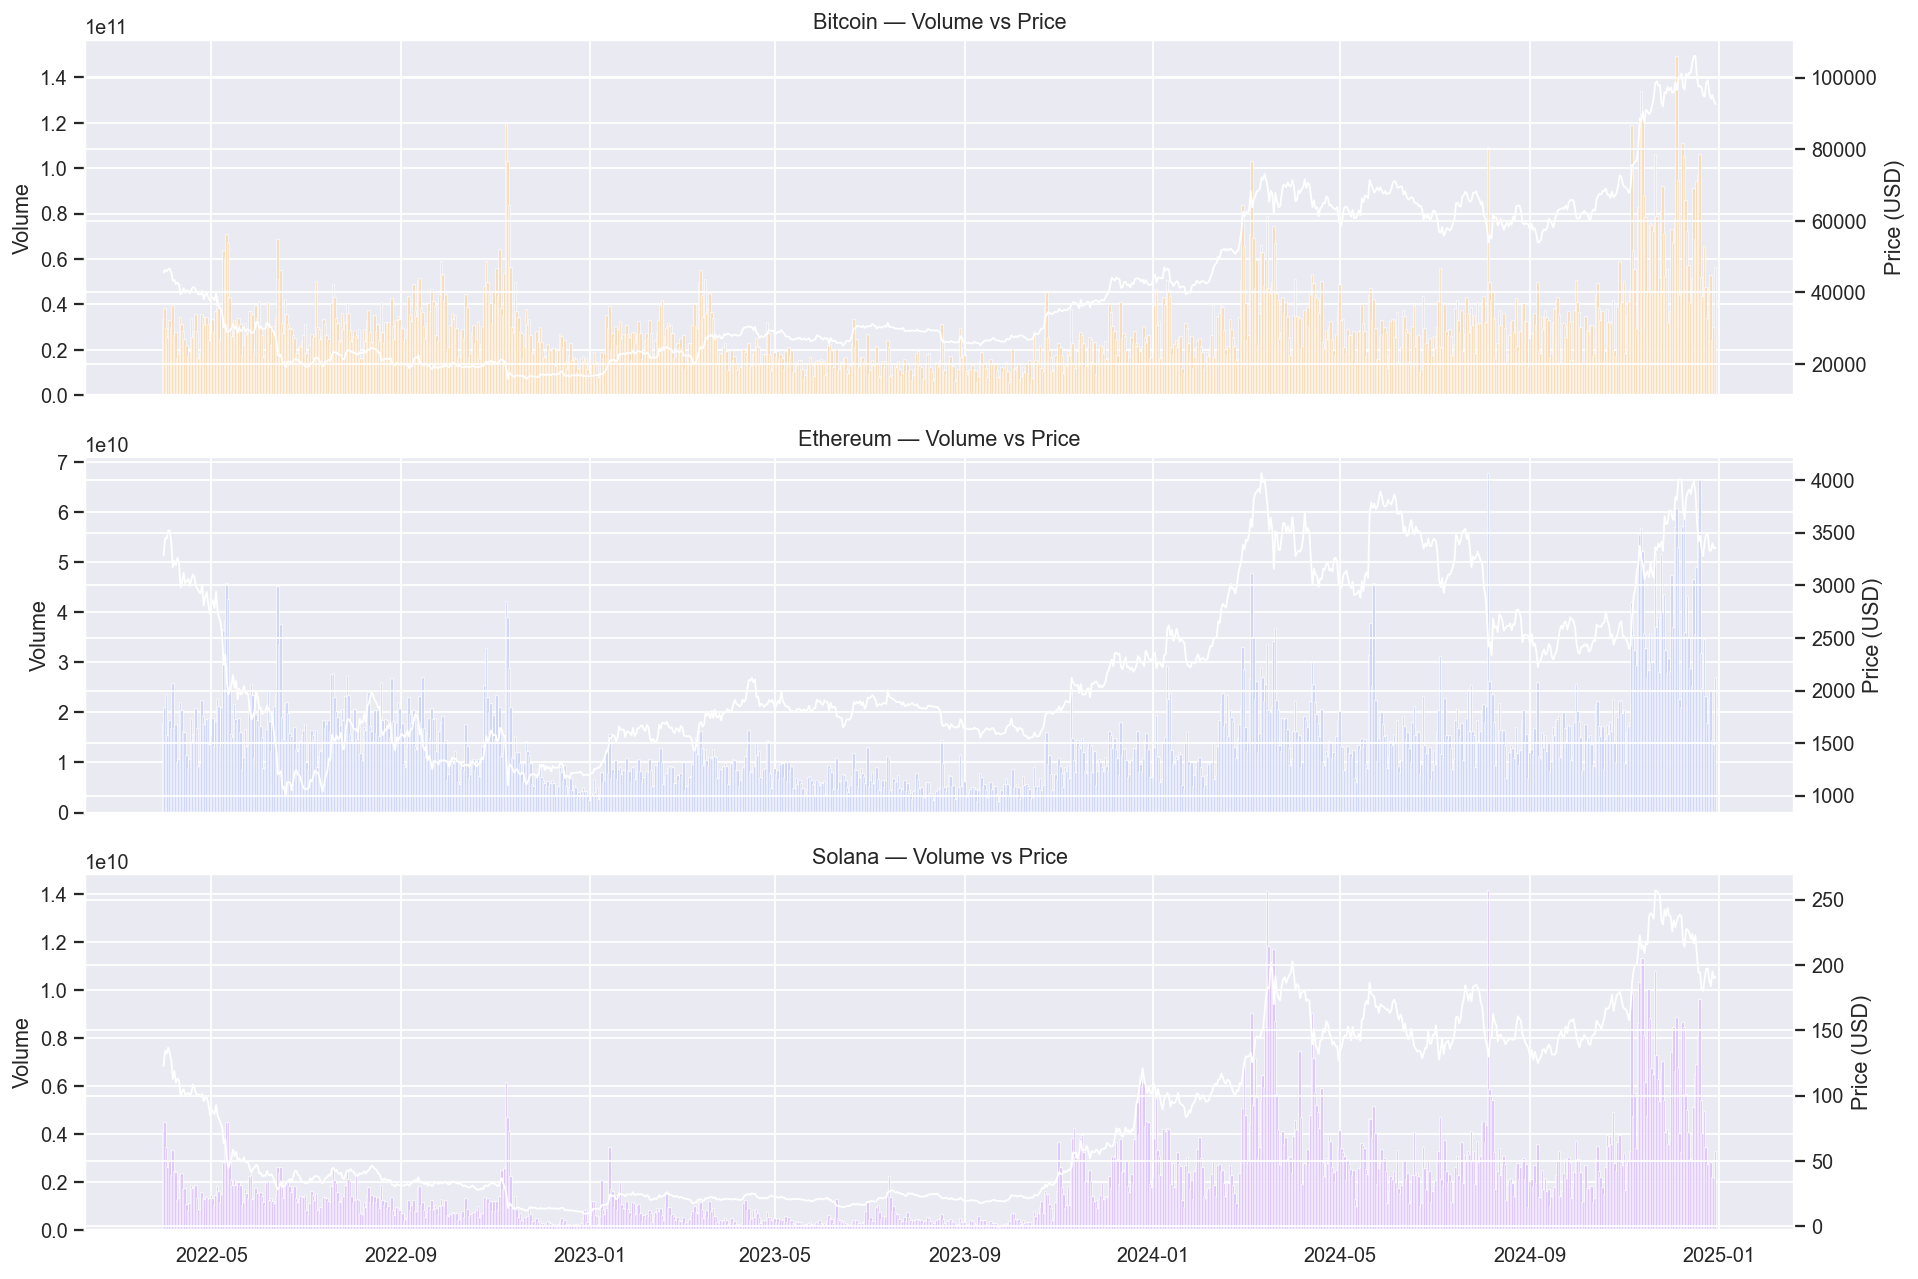

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

for ax, df, name, color in zip(
    axes,
    [btc, eth, sol],
    ['Bitcoin', 'Ethereum', 'Solana'],
    ['#F7931A', '#627EEA', '#9945FF']
):
    ax.bar(df.index, df['volume'], color=color, alpha=0.6, width=1)
    ax2 = ax.twinx()
    ax2.plot(df.index, df['close'], color='white', linewidth=1)
    ax.set_title(f'{name} — Volume vs Price')
    ax.set_ylabel('Volume')
    ax2.set_ylabel('Price (USD)')

plt.tight_layout()
plt.savefig('../data/volume_analysis.png', dpi=150)
plt.show()